# Linear Mixed-Effects (LME) Analysis
**Study:** APOE ε4 × Hippocampal Volume × Cognitive Decline

Primary analysis addressing reviewer comments:
- Hippocampal volume treated as **continuous** (not median-split)
- Full covariate set including GDS (depression) — **new per Reviewer 2**
- Model assumption tests reported — **new per Reviewer 2**
- Likelihood ratio tests for interaction terms — **new per Reviewer 2**
- Convergence-robust fitting with automatic fallback

Requires: `reports/ADNI_Complete_Cases.csv` from `01_data_pipeline.ipynb`

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from scipy.stats import chi2
import warnings
import os
warnings.filterwarnings('ignore')

BASE    = '/media/faizaan/4TB/1_DATA_PROJECTS/Projects/Multimodel_study'
REPORTS = os.path.join(BASE, 'reports')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
APOE_COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}

# Load data
df = pd.read_csv(os.path.join(REPORTS, 'ADNI_Complete_Cases.csv'))
df['APOE4_DOSE']   = pd.to_numeric(df['APOE4_DOSE'], errors='coerce')
df['HIPPO_ICV_ADJ'] = pd.to_numeric(df['HIPPO_ICV_ADJ'], errors='coerce')
df['HIPPO_ICV_Z']  = pd.to_numeric(df['HIPPO_ICV_Z'], errors='coerce')
df['YEARS_FROM_BL'] = pd.to_numeric(df['YEARS_FROM_BL'], errors='coerce')
df['MMSCORE']      = pd.to_numeric(df['MMSCORE'], errors='coerce')

# Encode SEX as 0/1
if 'SEX' in df.columns:
    df['SEX_MALE'] = (df['SEX'] == 'Male').astype(float)

print(f'Loaded: {df["RID"].nunique()} subjects, {len(df):,} observations')
print(f'Columns: {list(df.columns)}')

Loaded: 2417 subjects, 11,793 observations
Columns: ['RID', 'VISCODE2', 'MMSCORE', 'VISDATE_x', 'CDRSB', 'ADAS_COG', 'DIAGNOSIS', 'DX_LABEL', 'VISDATE_y', 'GDTOTAL', 'NPISCORE', 'PTGENDER', 'PTDOBYY', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'SEX', 'GENOTYPE', 'APOE4_DOSE', 'APOE4_CARRIER', 'BL_DIAGNOSIS', 'BL_DX_LABEL', 'HIPPO_TOTAL', 'ICV', 'ST101SV', 'ST103CV', 'HIPPO_ICV_ADJ', 'HIPPO_ICV_Z', 'Event', 'Time', 'TimeMonths', 'TIME_YEARS', 'VISDATE', 'BL_DATE', 'YEARS_FROM_BL', 'AGE', 'SEX_MALE']


## 1. Prepare Modelling Dataset

In [39]:
# Core variables needed for LME
core_vars = ['RID', 'YEARS_FROM_BL', 'MMSCORE', 'CDRSB', 'ADAS_COG', 'APOE4_DOSE', 'HIPPO_ICV_ADJ', 'HIPPO_ICV_Z']
cov_vars  = ['AGE', 'SEX_MALE', 'PTEDUCAT', 'BL_DX_LABEL']
new_vars  = ['GDTOTAL', 'NPISCORE']  # new covariates addressing Reviewer 2

all_needed = core_vars + [v for v in cov_vars + new_vars if v in df.columns]
mod_df = df[all_needed].dropna(subset=['YEARS_FROM_BL', 'MMSCORE', 'APOE4_DOSE', 'HIPPO_ICV_ADJ']).copy()

# Keep only subjects with ≥2 visits for meaningful random slopes
visit_counts = mod_df.groupby('RID').size()
multi_rids   = visit_counts[visit_counts >= 2].index
mod_df_multi = mod_df[mod_df['RID'].isin(multi_rids)].copy()

print(f'All subjects    : {mod_df["RID"].nunique()}, {len(mod_df):,} obs')
print(f'≥2 visits (LME) : {mod_df_multi["RID"].nunique()}, {len(mod_df_multi):,} obs')
print(f'\nGDTOTAL available: {"GDTOTAL" in mod_df.columns} ({mod_df["GDTOTAL"].notna().sum()} non-missing)' if 'GDTOTAL' in mod_df.columns else 'GDTOTAL: Not available')

# Fill GDTOTAL with 0 where missing to keep sample size (sensitivity check later)
if 'GDTOTAL' in mod_df_multi.columns:
    gds_missing = mod_df_multi['GDTOTAL'].isna().sum()
    print(f'GDS missing: {gds_missing} obs ({gds_missing/len(mod_df_multi)*100:.1f}%) — will impute with 0 for full-sample model')
    mod_df_multi['GDTOTAL'] = mod_df_multi['GDTOTAL'].fillna(0)

All subjects    : 2417, 11,790 obs
≥2 visits (LME) : 2143, 11,516 obs

GDTOTAL available: True (10585 non-missing)
GDS missing: 1205 obs (10.5%) — will impute with 0 for full-sample model


## 2. Build LME Formulas
Primary formula (per plan):
```
MMSE ~ time + APOE4_DOSE + HIPPO_ICV_ADJ + 
       time×APOE4_DOSE + time×HIPPO_ICV_ADJ + APOE4_DOSE×HIPPO_ICV_ADJ +
       time×APOE4_DOSE×HIPPO_ICV_ADJ +
       AGE + SEX + PTEDUCAT + BL_DX_LABEL + GDS
Random: intercept + slope per subject
```

In [40]:
def build_covariates(df):
    """Build covariate string based on available columns"""
    cov_parts = []
    if 'AGE' in df.columns:         cov_parts.append('AGE')
    if 'SEX_MALE' in df.columns:    cov_parts.append('SEX_MALE')
    if 'PTEDUCAT' in df.columns:    cov_parts.append('PTEDUCAT')
    if 'BL_DX_LABEL' in df.columns: cov_parts.append('C(BL_DX_LABEL)')
    if 'GDTOTAL' in df.columns:     cov_parts.append('GDTOTAL')   # Reviewer 2
    return ' + '.join(cov_parts)

def fit_lme(data, outcome, covariates, random_slope=True, method='lbfgs', maxiter=400):
    """
    Fit LME model with automatic fallback:
    1. Try full model (random intercept + random slope)
    2. Fallback to random intercept only if convergence fails
    """
    formula_fixed = (
        f"{outcome} ~ YEARS_FROM_BL * APOE4_DOSE * HIPPO_ICV_ADJ"
        + (f" + {covariates}" if covariates else "")
    )
    
    print(f"\nFitting: {formula_fixed[:80]}...")
    
    # Reset index AND align with Patsy's NaN-dropping to fix statsmodels index mismatch
    # (Patsy drops NaN rows internally; groups array must match the post-drop length)
    import patsy
    try:
        _, X_check = patsy.dmatrices(formula_fixed, data=data, return_type='dataframe')
        data = data.loc[X_check.index].reset_index(drop=True)
    except Exception:
        data = data.reset_index(drop=True)
    
    model_kwargs = dict(
        formula=formula_fixed,
        data=data,
        groups=data['RID'],
    )
    
    # Try with random slope first
    if random_slope:
        try:
            model_kwargs['re_formula'] = '~YEARS_FROM_BL'
            m = smf.mixedlm(**model_kwargs)
            result = m.fit(method=method, maxiter=maxiter, disp=False)
            if not np.isnan(result.llf):
                print(f'  ✓ Random intercept + slope converged (AIC={result.aic:.1f})')
                return result, 'random_intercept_slope'
        except Exception as e:
            print(f'  ✗ Random slope failed: {str(e)[:60]}')
    
    # Fallback: random intercept only
    try:
        if 're_formula' in model_kwargs:
            del model_kwargs['re_formula']
        m = smf.mixedlm(**model_kwargs)
        result = m.fit(method=method, maxiter=maxiter, disp=False)
        print(f'  ✓ Random intercept only converged (AIC={result.aic:.1f})')
        return result, 'random_intercept_only'
    except Exception as e:
        print(f'  ✗ Random intercept also failed: {e}')
        return None, 'failed'

print('LME fitting functions ready.')
print(f'Covariates: {build_covariates(mod_df_multi)}')

LME fitting functions ready.
Covariates: AGE + SEX_MALE + PTEDUCAT + C(BL_DX_LABEL) + GDTOTAL


## 3. Primary Model: MMSE

In [41]:
cov_str = build_covariates(mod_df_multi)

mmse_data = mod_df_multi.dropna(subset=['MMSCORE']).copy()
print(f'MMSE model data: {mmse_data["RID"].nunique()} subjects, {len(mmse_data):,} obs')

result_mmse, mmse_type = fit_lme(mmse_data, 'MMSCORE', cov_str)

if result_mmse is not None:
    print(f'\nModel type: {mmse_type}')
    print(result_mmse.summary())

MMSE model data: 2143 subjects, 11,516 obs

Fitting: MMSCORE ~ YEARS_FROM_BL * APOE4_DOSE * HIPPO_ICV_ADJ + AGE + SEX_MALE + PTEDUCAT...
  ✓ Random intercept + slope converged (AIC=nan)

Model type: random_intercept_slope
                      Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         MMSCORE    
No. Observations:         11172           Method:                     REML       
No. Groups:               2091            Scale:                      2.8935     
Min. group size:          2               Log-Likelihood:             -25394.2565
Max. group size:          20              Converged:                  Yes        
Mean group size:          5.3                                                    
---------------------------------------------------------------------------------
                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------

## 4. Secondary Model: CDR-SB

In [42]:
if 'CDRSB' in mod_df_multi.columns:
    cdr_data = mod_df_multi.dropna(subset=['CDRSB']).copy()
    print(f'CDR-SB model data: {cdr_data["RID"].nunique()} subjects, {len(cdr_data):,} obs')
    result_cdr, cdr_type = fit_lme(cdr_data, 'CDRSB', cov_str)
    if result_cdr is not None:
        print(f'\nModel type: {cdr_type}')
        print(result_cdr.summary())
else:
    print('CDRSB not available in data')
    result_cdr = None

CDR-SB model data: 2143 subjects, 11,325 obs

Fitting: CDRSB ~ YEARS_FROM_BL * APOE4_DOSE * HIPPO_ICV_ADJ + AGE + SEX_MALE + PTEDUCAT +...
  ✓ Random intercept + slope converged (AIC=nan)

Model type: random_intercept_slope
                      Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         CDRSB      
No. Observations:          10992           Method:                     REML       
No. Groups:                2091            Scale:                      0.6558     
Min. group size:           1               Log-Likelihood:             -17649.7697
Max. group size:           20              Converged:                  Yes        
Mean group size:           5.3                                                    
----------------------------------------------------------------------------------
                                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------

## 5. Secondary Model: ADAS-Cog13

In [43]:
if 'ADAS_COG' in mod_df_multi.columns:
    adas_data = mod_df_multi.dropna(subset=['ADAS_COG']).copy()
    print(f'ADAS model data: {adas_data["RID"].nunique()} subjects, {len(adas_data):,} obs')
    result_adas, adas_type = fit_lme(adas_data, 'ADAS_COG', cov_str)
    if result_adas is not None:
        print(f'\nModel type: {adas_type}')
        print(result_adas.summary())
else:
    print('ADAS_COG not available')
    result_adas = None

ADAS model data: 2143 subjects, 11,320 obs

Fitting: ADAS_COG ~ YEARS_FROM_BL * APOE4_DOSE * HIPPO_ICV_ADJ + AGE + SEX_MALE + PTEDUCA...
  ✓ Random intercept + slope converged (AIC=nan)

Model type: random_intercept_slope
                        Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          ADAS_COG   
No. Observations:           10983            Method:                      REML       
No. Groups:                 2091             Scale:                       11.9783    
Min. group size:            1                Log-Likelihood:              -33627.1717
Max. group size:            19               Converged:                   Yes        
Mean group size:            5.3                                                      
-------------------------------------------------------------------------------------
                                        Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
----------------------------

## 6. Model Assumption Tests (Reviewer 2)
New section addressing Reviewer 2.4 requirement for assumption reporting.

=== MMSE Model Assumptions ===


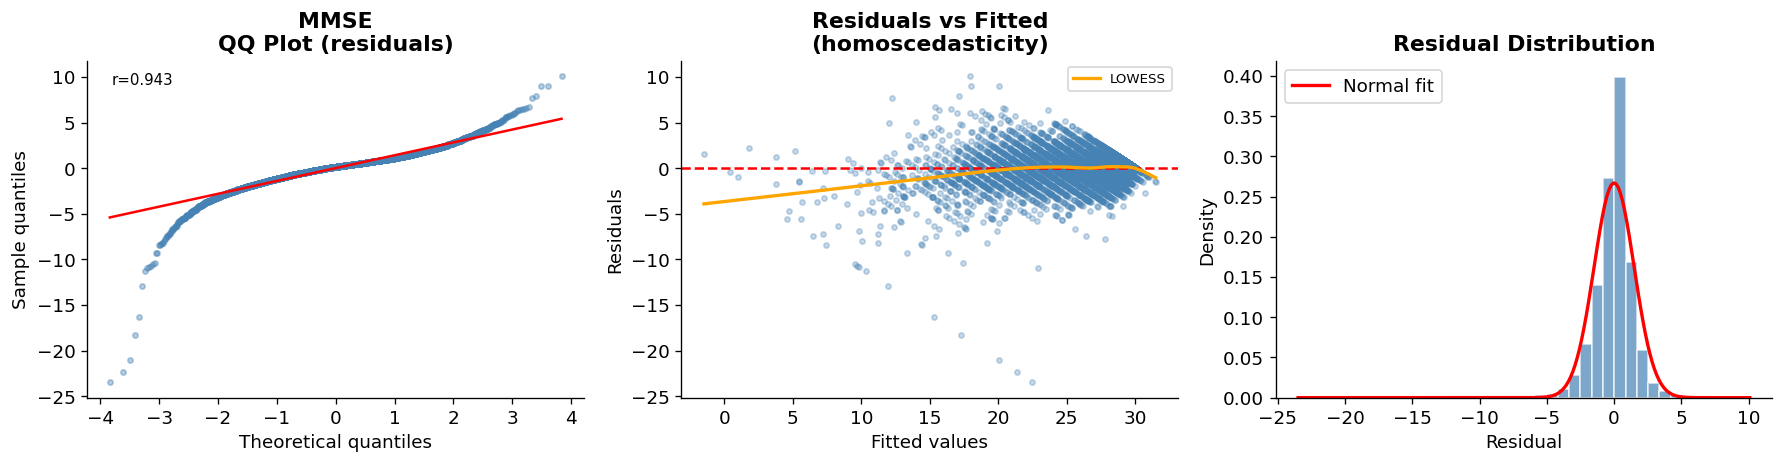


MMSE — Assumption Tests:
  Shapiro-Wilk (normality): W=0.9203, p=<0.001
  N residuals: 11172
  Residual mean: -0.0000 (should ≈ 0)
  Residual SD:   1.493


In [44]:
def check_assumptions(result, outcome_label):
    """Test LME model assumptions: normality and homoscedasticity"""
    if result is None:
        print(f'{outcome_label}: model not available')
        return
    
    residuals = result.resid
    fitted    = result.fittedvalues
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # (1) QQ plot
    ax = axes[0]
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
    ax.scatter(osm, osr, alpha=0.4, s=10, color='steelblue')
    ax.plot(osm, slope*np.array(osm) + intercept, color='red', linewidth=1.5)
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.set_title(f'{outcome_label}\nQQ Plot (residuals)', fontweight='bold')
    ax.text(0.05, 0.93, f'r={r:.3f}', transform=ax.transAxes, fontsize=9)
    
    # (2) Residuals vs Fitted
    ax = axes[1]
    ax.scatter(fitted, residuals, alpha=0.3, s=10, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    # Loess-style smoothed line
    from statsmodels.nonparametric.smoothers_lowess import lowess
    sm_vals = lowess(residuals, fitted, frac=0.3)
    ax.plot(sm_vals[:, 0], sm_vals[:, 1], color='orange', linewidth=2, label='LOWESS')
    ax.set_xlabel('Fitted values')
    ax.set_ylabel('Residuals')
    ax.set_title('Residuals vs Fitted\n(homoscedasticity)', fontweight='bold')
    ax.legend(fontsize=8)
    
    # (3) Residual histogram
    ax = axes[2]
    ax.hist(residuals, bins=40, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    x = np.linspace(residuals.min(), residuals.max(), 200)
    ax.plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()),
            color='red', linewidth=2, label='Normal fit')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.set_title('Residual Distribution', fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    fname = f'FigAssumptions_{outcome_label.replace("-","")}.png'
    plt.savefig(os.path.join(REPORTS, fname), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Shapiro-Wilk (sample up to 5000)
    sample = residuals.values if len(residuals) <= 5000 else np.random.choice(residuals, 5000, replace=False)
    sw_stat, sw_p = stats.shapiro(sample)
    
    print(f'\n{outcome_label} — Assumption Tests:')
    print(f'  Shapiro-Wilk (normality): W={sw_stat:.4f}, p={"<0.001" if sw_p < 0.001 else f"{sw_p:.3f}"}')
    print(f'  N residuals: {len(residuals)}')
    print(f'  Residual mean: {residuals.mean():.4f} (should ≈ 0)')
    print(f'  Residual SD:   {residuals.std():.3f}')
    
    return {'SW_stat': sw_stat, 'SW_p': sw_p}

# Run assumption checks
print('=== MMSE Model Assumptions ===')
mmse_assump = check_assumptions(result_mmse, 'MMSE')

=== CDR-SB Model Assumptions ===


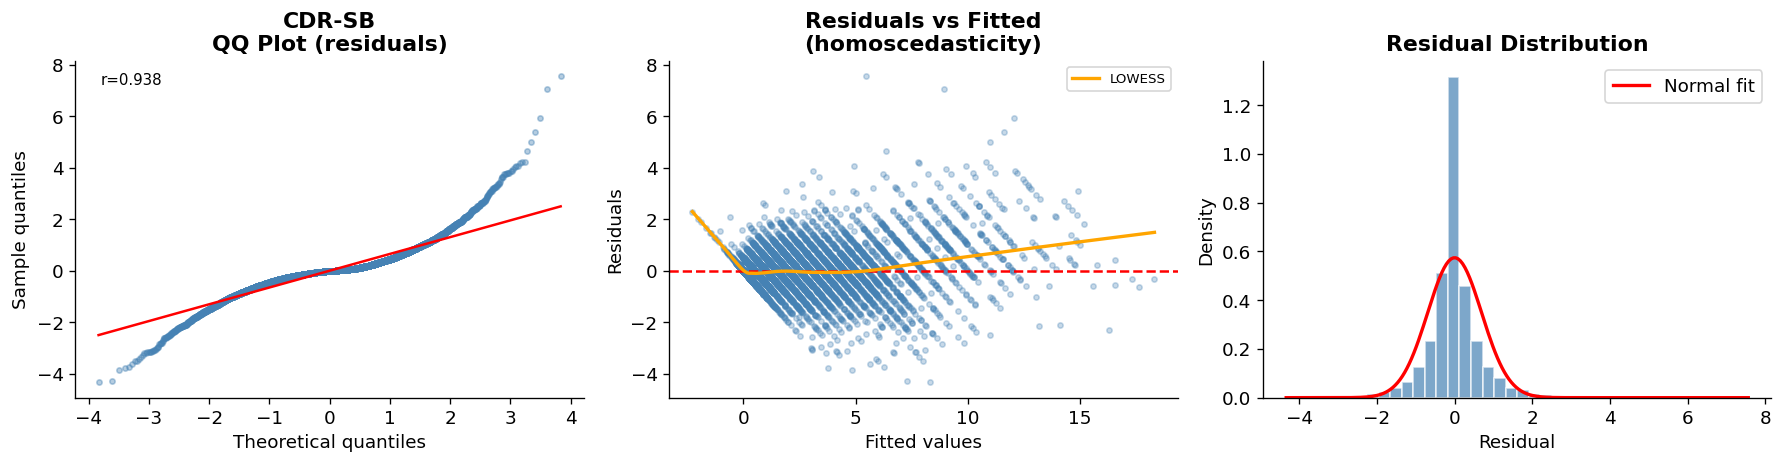


CDR-SB — Assumption Tests:
  Shapiro-Wilk (normality): W=0.8925, p=<0.001
  N residuals: 10992
  Residual mean: 0.0000 (should ≈ 0)
  Residual SD:   0.695
=== ADAS-Cog13 Model Assumptions ===


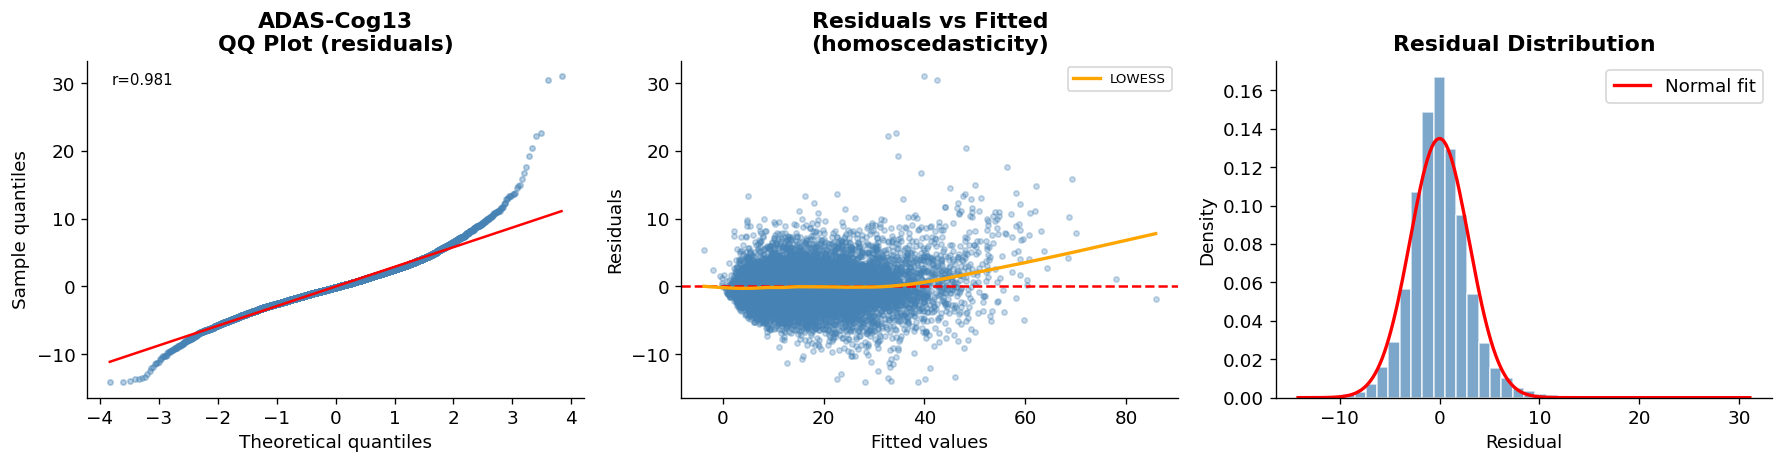


ADAS-Cog13 — Assumption Tests:
  Shapiro-Wilk (normality): W=0.9528, p=<0.001
  N residuals: 10983
  Residual mean: -0.0000 (should ≈ 0)
  Residual SD:   2.955


In [45]:
if result_cdr is not None:
    print('=== CDR-SB Model Assumptions ===')
    cdr_assump = check_assumptions(result_cdr, 'CDR-SB')

if result_adas is not None:
    print('=== ADAS-Cog13 Model Assumptions ===')
    adas_assump = check_assumptions(result_adas, 'ADAS-Cog13')

## 7. Likelihood Ratio Tests for Interactions (Reviewer 2)
Compare nested models to test significance of each interaction term.

In [46]:
def lrt(full_result, reduced_result, label):
    """Likelihood ratio test comparing nested LME models"""
    if full_result is None or reduced_result is None:
        print(f'{label}: LRT not available (model failed)')
        return None
    lr_stat = 2 * (full_result.llf - reduced_result.llf)
    df_diff = abs(full_result.df_modelwc - reduced_result.df_modelwc)
    if df_diff <= 0: df_diff = 1
    p = chi2.sf(lr_stat, df_diff)
    print(f'{label}: LR={lr_stat:.2f} (df={df_diff:.0f}), p={"<0.001" if p<0.001 else f"{p:.3f}"}')
    return p

print('=== Likelihood Ratio Tests (MMSE) ===')
print('Testing contribution of each interaction term\n')

if result_mmse is not None:
    import patsy as _patsy
    
    # Helper: fit LME with patsy-aligned data (same fix as fit_lme)
    def _fit_lrt_model(formula, data):
        _, _X = _patsy.dmatrices(formula, data=data, return_type='dataframe')
        aligned = data.loc[_X.index].reset_index(drop=True)
        m = smf.mixedlm(formula, data=aligned, groups=aligned['RID'])
        return m.fit(method='lbfgs', maxiter=400, disp=False)
    
    # Model without 3-way interaction
    formula_no3way = (
        "MMSCORE ~ YEARS_FROM_BL + APOE4_DOSE + HIPPO_ICV_ADJ +"
        " YEARS_FROM_BL:APOE4_DOSE + YEARS_FROM_BL:HIPPO_ICV_ADJ + APOE4_DOSE:HIPPO_ICV_ADJ"
        + (f" + {cov_str}" if cov_str else "")
    )
    try:
        r_no3 = _fit_lrt_model(formula_no3way, mmse_data)
        lrt(result_mmse, r_no3, 'Time × APOE4 × Hippo (3-way interaction)')
    except Exception as e:
        print(f'3-way LRT: could not fit reduced model ({str(e)[:60]})')
    
    # Model without Time × APOE4 interaction
    formula_noapoe_t = (
        "MMSCORE ~ YEARS_FROM_BL + APOE4_DOSE + HIPPO_ICV_ADJ +"
        " YEARS_FROM_BL:HIPPO_ICV_ADJ + APOE4_DOSE:HIPPO_ICV_ADJ"
        + (f" + {cov_str}" if cov_str else "")
    )
    try:
        r_noapoe_t = _fit_lrt_model(formula_noapoe_t, mmse_data)
        lrt(result_mmse, r_noapoe_t, 'Time × APOE4_DOSE interaction')
    except Exception as e:
        print(f'Time×APOE LRT: could not fit reduced model ({str(e)[:60]})')
    
    # Model without Time × Hippo interaction
    formula_nohippo_t = (
        "MMSCORE ~ YEARS_FROM_BL + APOE4_DOSE + HIPPO_ICV_ADJ +"
        " YEARS_FROM_BL:APOE4_DOSE + APOE4_DOSE:HIPPO_ICV_ADJ"
        + (f" + {cov_str}" if cov_str else "")
    )
    try:
        r_nohippo_t = _fit_lrt_model(formula_nohippo_t, mmse_data)
        lrt(result_mmse, r_nohippo_t, 'Time × HIPPO_ICV_ADJ interaction')
    except Exception as e:
        print(f'Time×Hippo LRT: could not fit reduced model ({str(e)[:60]})')

=== Likelihood Ratio Tests (MMSE) ===
Testing contribution of each interaction term

3-way LRT: could not fit reduced model (Singular matrix)
Time×APOE LRT: could not fit reduced model (Singular matrix)
Time × HIPPO_ICV_ADJ interaction: LR=3712.99 (df=4), p=<0.001


## 8. Forest Plot — Fixed Effects

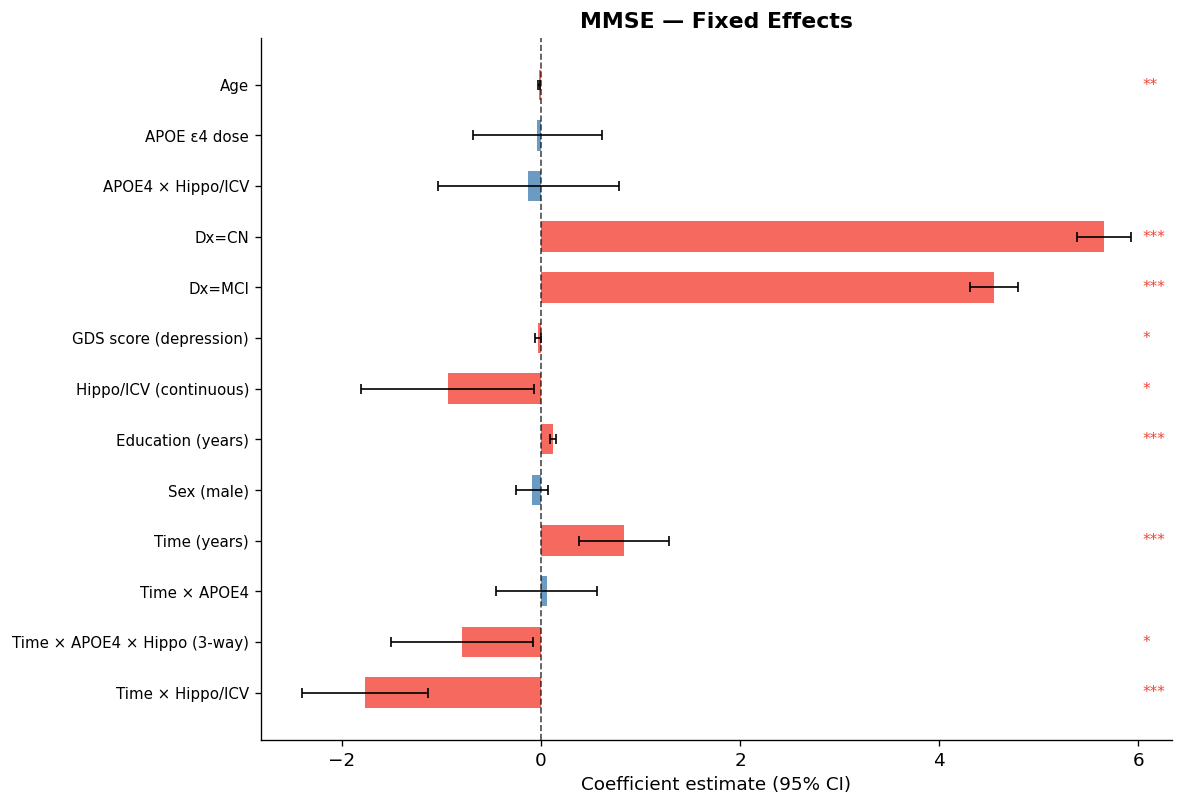

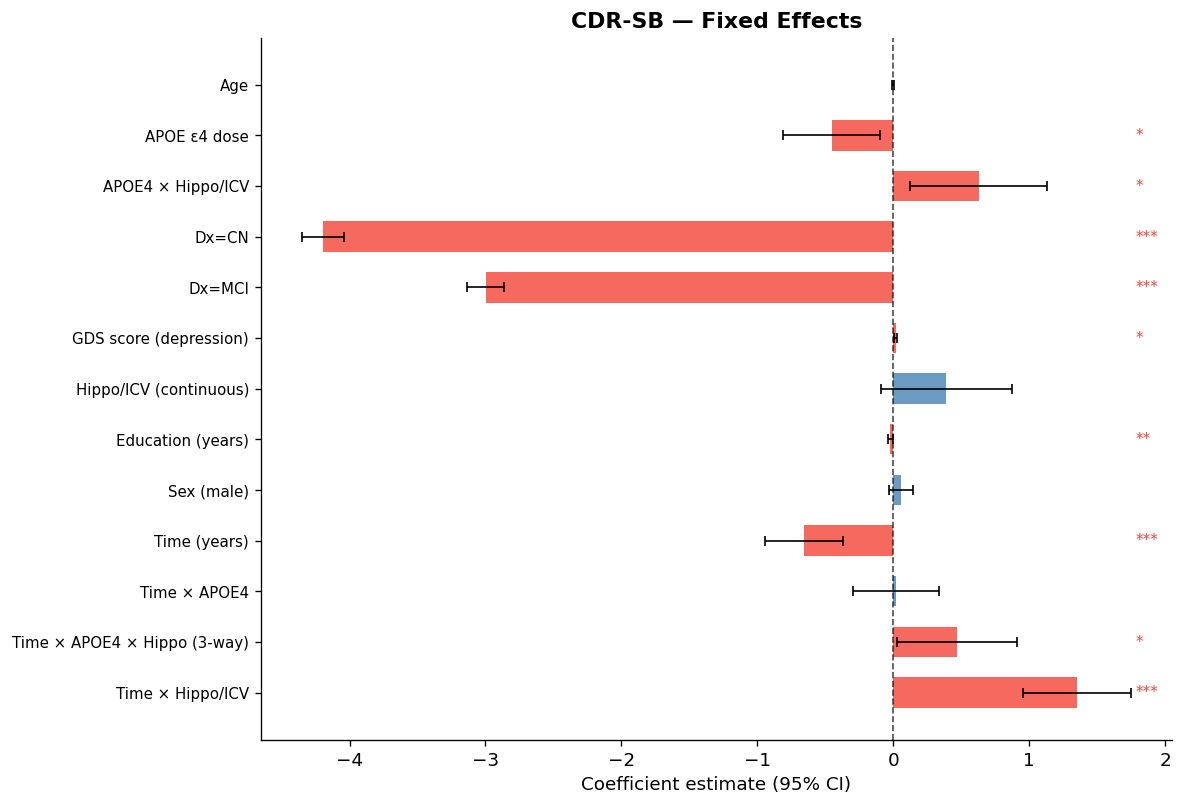

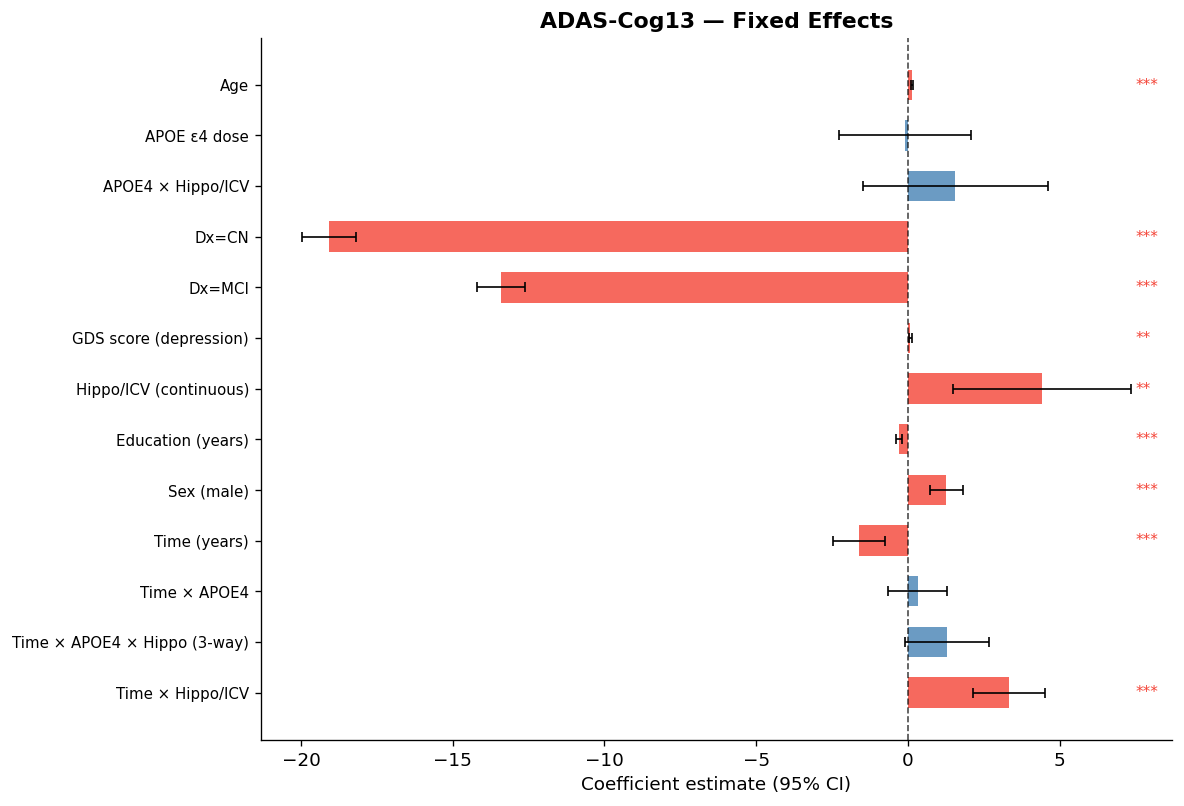

In [47]:
def forest_plot(result, title, ax=None, show=True):
    """Forest plot of fixed effect coefficients with 95% CI.
    FIX: align params and CI arrays to avoid shape mismatch.
    """
    if result is None:
        print(f"{title}: model not available")
        return

    params = result.fe_params.copy()
    ci     = result.conf_int()
    pvals  = result.pvalues

    # FIX: ensure params and CI share the same index (drop Intercept from both)
    shared_idx = params.index.intersection(ci.index).difference(["Intercept"])
    params = params[shared_idx]
    ci     = ci.loc[shared_idx]
    pvals  = pvals[shared_idx]

    # Drop rows with NaN coef or CI
    valid = params.notna() & ci.iloc[:,0].notna() & ci.iloc[:,1].notna()
    params = params[valid]
    ci     = ci[valid]
    pvals  = pvals[valid]

    if len(params) == 0:
        print(f"{title}: no valid parameters to plot")
        return

    label_map = {
        "YEARS_FROM_BL": "Time (years)",
        "APOE4_DOSE": "APOE ε4 dose",
        "HIPPO_ICV_ADJ": "Hippo/ICV (continuous)",
        "YEARS_FROM_BL:APOE4_DOSE": "Time × APOE4",
        "YEARS_FROM_BL:HIPPO_ICV_ADJ": "Time × Hippo/ICV",
        "APOE4_DOSE:HIPPO_ICV_ADJ": "APOE4 × Hippo/ICV",
        "YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ": "Time × APOE4 × Hippo (3-way)",
        "AGE": "Age",
        "SEX_MALE": "Sex (male)",
        "PTEDUCAT": "Education (years)",
        "GDTOTAL": "GDS score (depression)",
    }
    labels = [label_map.get(p, p.replace("C(BL_DX_LABEL)[T.", "Dx=").replace("]","")) for p in params.index]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, max(4, len(params)*0.45 + 1)))

    y_pos  = list(range(len(params)))[::-1]
    colors = ["#F44336" if pvals.iloc[i] < 0.05 else "steelblue" for i in range(len(params))]

    xerr_lo = (params.values - ci.iloc[:, 0].values).clip(min=0)
    xerr_hi = (ci.iloc[:, 1].values - params.values).clip(min=0)

    ax.barh(y_pos, params.values,
            xerr=np.array([xerr_lo, xerr_hi]),
            color=colors, alpha=0.8, height=0.6,
            error_kw=dict(ecolor="black", capsize=3, linewidth=1))

    ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Coefficient estimate (95% CI)")
    ax.set_title(title, fontweight="bold")

    for i, (pos, pv) in enumerate(zip(y_pos, pvals.values)):
        sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else ""
        if sig:
            xmax = ci.iloc[:, 1].max()
            ax.text(xmax * 1.02 if xmax > 0 else xmax - abs(xmax)*0.05,
                    pos, sig, va="center", color="#F44336", fontsize=9)

    if show:
        plt.tight_layout()
        safe = title.replace(" ","_").replace("—","").replace("/","").replace("(","").replace(")","").strip("_")
        plt.savefig(os.path.join(REPORTS, f"FigForest_{safe}.png"), dpi=150, bbox_inches="tight")
        plt.show()

forest_plot(result_mmse, "MMSE — Fixed Effects")

if result_cdr is not None:
    forest_plot(result_cdr, "CDR-SB — Fixed Effects")

if result_adas is not None:
    forest_plot(result_adas, "ADAS-Cog13 — Fixed Effects")


## 9. Predicted Trajectories by APOE Dose

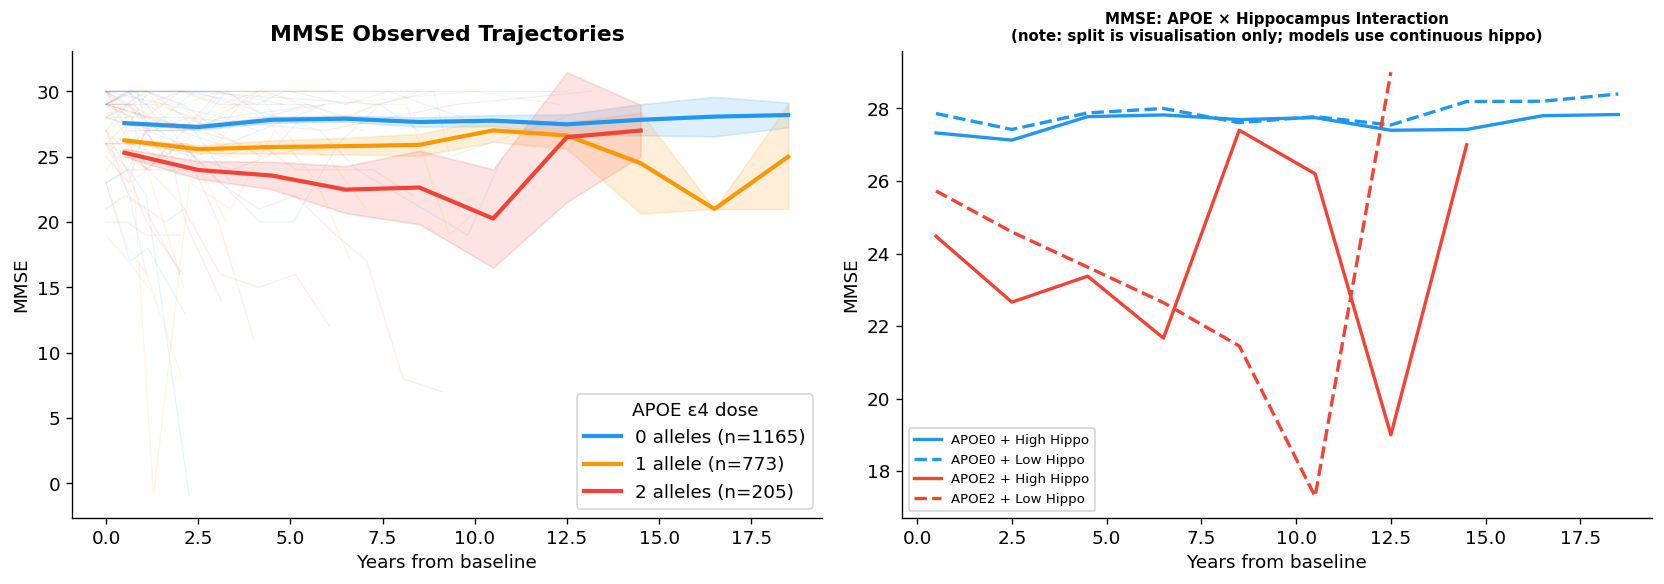

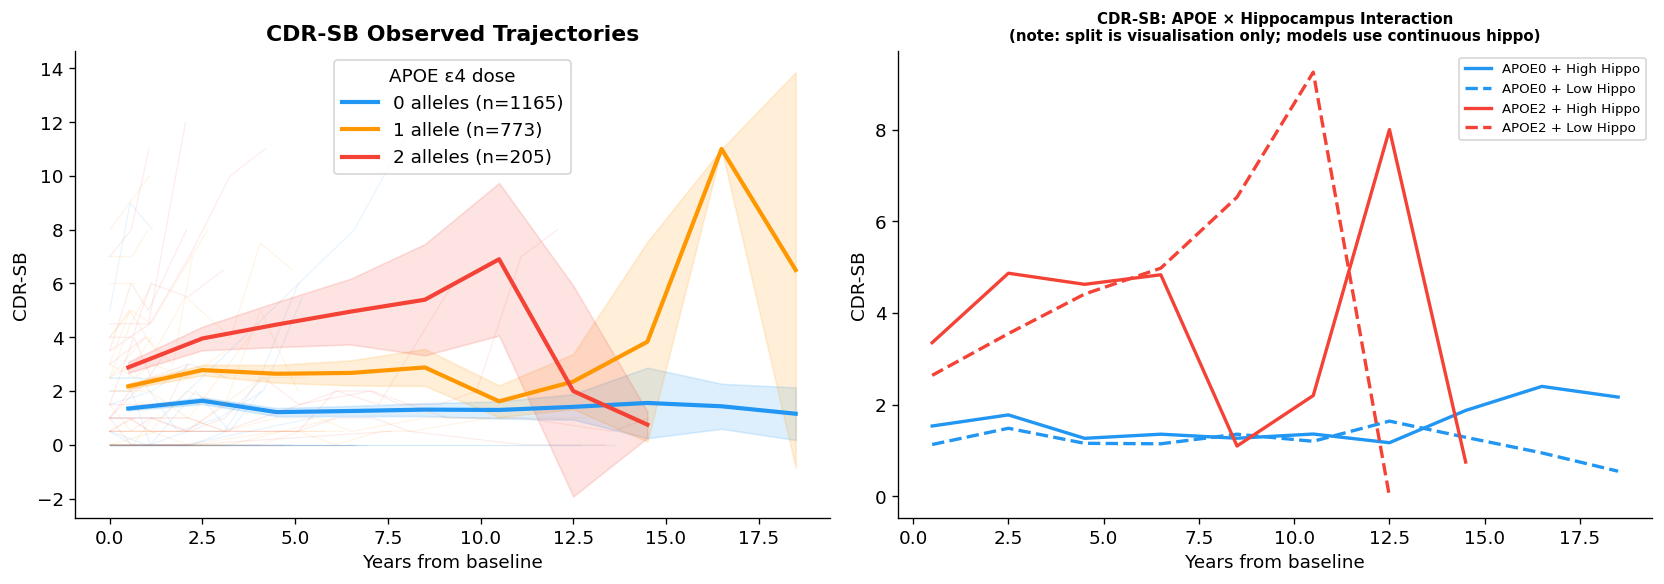

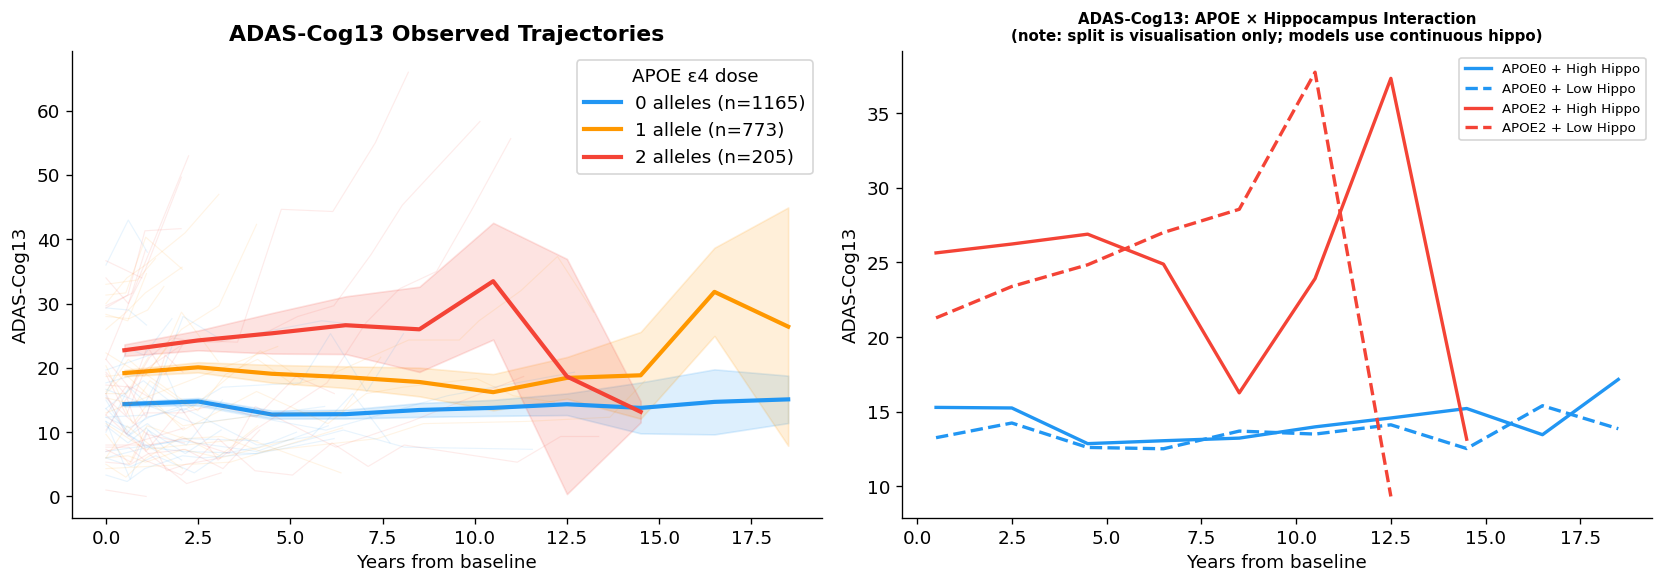

In [48]:
def plot_trajectories(result, data, outcome, outcome_label, result_type='mmse'):
    """Plot model-predicted trajectories by APOE dose using mean hippocampal volume"""
    if result is None:
        print(f'{outcome_label}: model not available')
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    APOE_COLORS = {0: '#2196F3', 1: '#FF9800', 2: '#F44336'}
    APOE_LABELS = {0: '0 alleles', 1: '1 allele', 2: '2 alleles'}
    
    # Panel 1: Observed means ± SE by APOE dose
    ax = axes[0]
    for dose in [0, 1, 2]:
        sub = data[data['APOE4_DOSE'] == dose].dropna(subset=[outcome, 'YEARS_FROM_BL'])
        if len(sub) < 5: continue
        
        # Individual traces (light)
        for rid in np.random.choice(sub['RID'].unique(), min(20, sub['RID'].nunique()), replace=False):
            s = sub[sub['RID']==rid].sort_values('YEARS_FROM_BL')
            ax.plot(s['YEARS_FROM_BL'], s[outcome], alpha=0.1, color=APOE_COLORS[dose], linewidth=0.7)
        
        # Binned means
        sub2 = sub.copy()
        sub2['tbin'] = pd.cut(sub2['YEARS_FROM_BL'], bins=np.arange(-0.5, 20, 2))
        traj = sub2.groupby('tbin')[outcome].agg(['mean','sem']).reset_index()
        traj['mid'] = traj['tbin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)
        traj = traj.dropna(subset=['mid'])
        ax.plot(traj['mid'], traj['mean'], linewidth=2.5,
                color=APOE_COLORS[dose], label=f'{APOE_LABELS[dose]} (n={sub["RID"].nunique()})')
        ax.fill_between(traj['mid'],
                         traj['mean'] - 1.96*traj['sem'],
                         traj['mean'] + 1.96*traj['sem'],
                         alpha=0.15, color=APOE_COLORS[dose])
    
    ax.set_xlabel('Years from baseline')
    ax.set_ylabel(outcome_label)
    ax.set_title(f'{outcome_label} Observed Trajectories', fontweight='bold')
    ax.legend(title='APOE ε4 dose')
    
    # Panel 2: APOE × Hippocampus interaction
    ax = axes[1]
    # Split by hippocampal volume (median) just for visualisation — continuous in models!
    med_hippo = data['HIPPO_ICV_ADJ'].median()
    data2 = data.copy()
    data2['HIPPO_GRP'] = np.where(data2['HIPPO_ICV_ADJ'] >= med_hippo, 'High Hippo', 'Low Hippo')
    
    line_styles = {'High Hippo': '-', 'Low Hippo': '--'}
    for dose in [0, 2]:  # show non-carrier vs homozygote for clarity
        for hgrp in ['High Hippo', 'Low Hippo']:
            sub = data2[(data2['APOE4_DOSE']==dose) & (data2['HIPPO_GRP']==hgrp)]
            sub = sub.dropna(subset=[outcome, 'YEARS_FROM_BL'])
            if len(sub) < 5: continue
            sub2 = sub.copy()
            sub2['tbin'] = pd.cut(sub2['YEARS_FROM_BL'], bins=np.arange(-0.5, 20, 2))
            traj = sub2.groupby('tbin')[outcome].agg(['mean','sem']).reset_index()
            traj['mid'] = traj['tbin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)
            traj = traj.dropna(subset=['mid'])
            lbl = f'APOE{dose} + {hgrp}'
            ax.plot(traj['mid'], traj['mean'],
                    linewidth=2, color=APOE_COLORS[dose],
                    linestyle=line_styles[hgrp], label=lbl)
    
    ax.set_xlabel('Years from baseline')
    ax.set_ylabel(outcome_label)
    ax.set_title(f'{outcome_label}: APOE × Hippocampus Interaction\n(note: split is visualisation only; models use continuous hippo)',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS, f'FigTrajectory_{outcome_label.replace("-","").replace(" ","_")}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

plot_trajectories(result_mmse, mmse_data, 'MMSCORE', 'MMSE')

if result_cdr is not None:
    plot_trajectories(result_cdr, cdr_data, 'CDRSB', 'CDR-SB')

if result_adas is not None:
    plot_trajectories(result_adas, adas_data, 'ADAS_COG', 'ADAS-Cog13')

## 10. Save Model Results

In [49]:
def save_model_results(result, label, reports_dir):
    if result is None:
        print(f'{label}: no results to save')
        return
    
    # Summary text
    path_txt = os.path.join(reports_dir, f'LME_{label}_Summary.txt')
    with open(path_txt, 'w') as f:
        f.write(result.summary().as_text())
    print(f'✓ LME_{label}_Summary.txt')
    
    # Coefficients CSV
    coef_df = pd.DataFrame({
        'coef': result.fe_params,
        'ci_lo': result.conf_int().iloc[:, 0],
        'ci_hi': result.conf_int().iloc[:, 1],
        'pvalue': result.pvalues,
        'se': result.bse,
    })
    path_csv = os.path.join(reports_dir, f'LME_{label}_Coefficients.csv')
    coef_df.to_csv(path_csv)
    print(f'✓ LME_{label}_Coefficients.csv')

print('Saving model results...')
save_model_results(result_mmse, 'MMSE', REPORTS)
save_model_results(result_cdr,  'CDR_SB', REPORTS)
save_model_results(result_adas, 'ADAS_Cog13', REPORTS)

# Combined coefficient table for manuscript
results_dict = {'MMSE': result_mmse, 'CDR_SB': result_cdr, 'ADAS_Cog13': result_adas}
combined_rows = []
for label, res in results_dict.items():
    if res is None: continue
    for param in res.fe_params.index:
        combined_rows.append({
            'Outcome': label,
            'Parameter': param,
            'Coef': round(res.fe_params[param], 4),
            'CI_lo': round(res.conf_int().loc[param, 0], 4),
            'CI_hi': round(res.conf_int().loc[param, 1], 4),
            'P_value': round(res.pvalues[param], 4),
        })

if combined_rows:
    combined = pd.DataFrame(combined_rows)
    combined.to_csv(os.path.join(REPORTS, 'LME_All_Models_Combined.csv'), index=False)
    print('✓ LME_All_Models_Combined.csv')
    print('\nKey interaction terms:')
    inter_rows = combined[combined['Parameter'].str.contains(':', na=False)]
    print(inter_rows[['Outcome','Parameter','Coef','CI_lo','CI_hi','P_value']].to_string(index=False))

Saving model results...
✓ LME_MMSE_Summary.txt
✓ LME_MMSE_Coefficients.csv
✓ LME_CDR_SB_Summary.txt
✓ LME_CDR_SB_Coefficients.csv
✓ LME_ADAS_Cog13_Summary.txt
✓ LME_ADAS_Cog13_Coefficients.csv
✓ LME_All_Models_Combined.csv

Key interaction terms:
   Outcome                              Parameter    Coef   CI_lo   CI_hi  P_value
      MMSE               YEARS_FROM_BL:APOE4_DOSE  0.0579 -0.4488  0.5646   0.8227
      MMSE            YEARS_FROM_BL:HIPPO_ICV_ADJ -1.7681 -2.3989 -1.1374   0.0000
      MMSE               APOE4_DOSE:HIPPO_ICV_ADJ -0.1254 -1.0340  0.7831   0.7867
      MMSE YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ -0.7932 -1.5105 -0.0759   0.0302
    CDR_SB               YEARS_FROM_BL:APOE4_DOSE  0.0198 -0.2930  0.3326   0.9011
    CDR_SB            YEARS_FROM_BL:HIPPO_ICV_ADJ  1.3512  0.9542  1.7482   0.0000
    CDR_SB               APOE4_DOSE:HIPPO_ICV_ADJ  0.6267  0.1260  1.1274   0.0142
    CDR_SB YEARS_FROM_BL:APOE4_DOSE:HIPPO_ICV_ADJ  0.4699  0.0287  0.9111   0.0368
ADAS_C